# Check whether the model is working

**NOTES:**
- The model needs finetuning before being evaluated.
- Currently only numerical features can be used

**LOGS**

- [Aug 14, 2025] - Attempted explainability method based on embeddings
  similiarities, didn't work. Resetting (instead of deleting features might work
  better). Tried both X -> y vs X\{i} -> y and X\\{i}Uy -> i vs X -> y
- [Aug 15, 2025] - Forward pass working for explainability. Required before setting up training:
    - [Aug 18] Double check the (original) target remains in the first index of the dataframe before forward pass
    - [Aug 18] Ensure the transformations over the original target don't delete the original feature
    - [Aug 18] Save/Load model
    - Find better postprocessing method for single feature PFN predictions (std/mean?)
    - Handle feature transformations better
    - TODO: Test removing any std or mean corrections to the predicted values (!!!)
- [Aug 18, 2025] - Added more tests to this notebook + Went through friday's checklist
- [Aug 21, 2025] - 

In [1]:
import sys
sys.path.append("../")
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from mlresearch.datasets import BinaryDatasets
from explainerpfn.base import SingleFeatureExplainerPFN

# just a simple toy dataset (all continuous features)

datasets = BinaryDatasets(names=["BANKNOTE AUTHENTICATION"]).download()
df = datasets["BANKNOTE AUTHENTICATION"]

df_train_rf = df.sample(500, replace=False, random_state=42)
df_train = df.drop(df_train_rf.index).sample(500, replace=False, random_state=42)
df_test = df.drop(df_train_rf.index).drop(df_train.index)

# preprocess data (standardscaler)
scaler = StandardScaler().fit(df_train_rf.loc[:, df_train_rf.columns.drop("target")].values)

Xy = []
for df_ in [df_train_rf, df_train, df_test]:
    df_ = df_.reset_index(drop=True)
    df_.loc[:, df_.columns.drop("target")] = scaler.transform(df_.loc[:, df_.columns.drop("target")].values)
    X = df_.loc[:, df_.columns.drop("target")].values
    y = df_["target"].values
    Xy.append((X, y))

(X_train_rf, y_train_rf), (X_train, _), (X_test, _) = Xy

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

# Get a classifier, predictions and SHAP explanations

In [2]:
clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
clf.fit(X_train_rf, y_train_rf)

y_train = clf.predict_proba(X_train)[:, 1]
y_test = clf.predict_proba(X_test)[:, 1]

In [3]:
def get_shap_values(X, model, masker=None):
    """
    Get SHAP values for the given model and data.
    """
    xai = shap.Explainer(
        model=model, 
        masker=masker
    )

    shap_explanation_train = xai(X).values[:, :, -1]

    return shap_explanation_train

In [4]:
all_shap_values = []
for X, y in tqdm(list(zip([X_train, X_test], [y_train, y_test])), desc="Calculating SHAP values"):
    X_shap = get_shap_values(X, clf, masker=X_train)
    df_shap = pd.DataFrame(X_shap.astype(float), columns=df_train.columns.drop("target"))
    df_shap["target"] = y
    all_shap_values.append((X_shap, df_shap))
    
(X_train_shap, df_shap_train), (X_test_shap, df_shap_test) = all_shap_values

Calculating SHAP values:   0%|          | 0/2 [00:00<?, ?it/s]

 97%|=================== | 725/744 [00:14<00:00]        

# PFN Explanations - Single feature

In [5]:
self = SingleFeatureExplainerPFN(feature_idx=1, random_state=42)
self.fit(X_train, y_train)

# averaged_logits, outputs, borders = self.forward(X, np.zeros_like(y), 0)
output = self.predict(X_test, y_test)

# Generate explanations for the entire dataset

In [6]:
explanations = np.zeros_like(X_test, dtype=float)
for i in tqdm(range(X_test.shape[1])):
    singlepfn = SingleFeatureExplainerPFN(feature_idx=i, softmax_temperature=0.9, random_state=42)
    singlepfn.fit(X_train, y_train)
    explanations[:, i] = singlepfn.predict(X_test, y_test)

  0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
# Apply correction to ensure additivity
base_value = np.mean(y_train)
error = (y_test - (explanations.sum(axis=1) + base_value))
error = np.repeat(error.reshape(-1, 1), repeats=explanations.shape[1], axis=1) / explanations.shape[1]
explanations_corrected = explanations + error

In [8]:
correlations = {}

# Correlation between input values and the predicted target
correlations["input_values"] = df.corr()["target"]

# Correlation between PFN explanations and the predicted target
df_explanations = pd.DataFrame(explanations.astype(float), columns=df_train.columns.drop("target"))
df_explanations["target"] = y_test
correlations["pfn_explanations"] = df_explanations.corr()["target"]

# Correlation between the corrected PFN explanations and the predicted target
df_explanations_corrected = pd.DataFrame(explanations_corrected.astype(float), columns=df_train.columns.drop("target"))
df_explanations_corrected["target"] = y_test
correlations["pfn_explanations_corrected"] = df_explanations_corrected.corr()["target"]

# Correlation between PFN explanations and SHAP values
correlations["pfn_explanations_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1] 
        for i in df_explanations_corrected.columns
    ],
    index=df_explanations_corrected.columns
)

pd.DataFrame(correlations)

,input_values,pfn_explanations,pfn_explanations_corrected,pfn_explanations_shap
0,-0.724843,0.973882,0.598113,0.692759
1,-0.444688,-0.040590,-0.050603,-0.170889
2,0.155883,-0.390217,-0.229449,-0.011395
3,-0.023424,0.154340,0.195145,0.166559
target,1.000000,1.000000,1.000000,1.000000


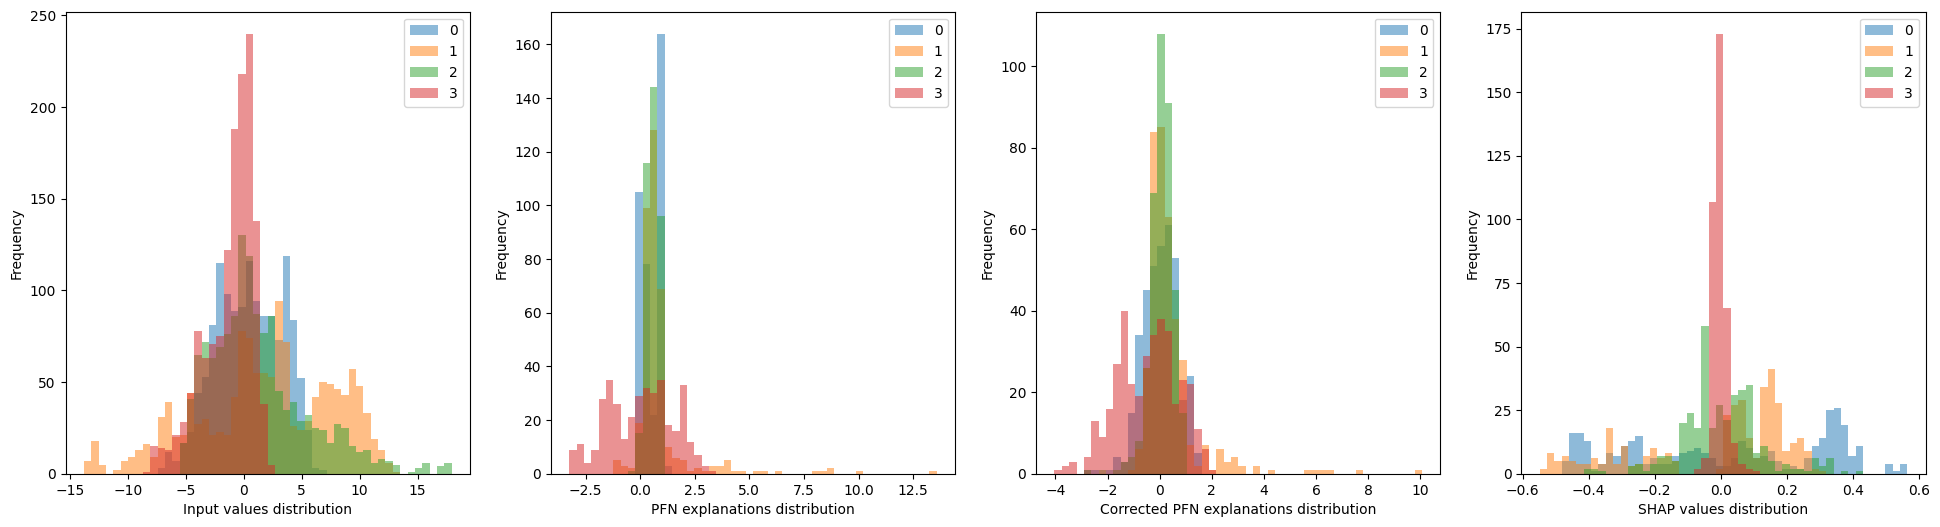

In [9]:
label_data = {
    "Input values": df.drop(columns="target"),
    "PFN explanations": df_explanations.drop(columns="target"),
    "Corrected PFN explanations": df_explanations_corrected.drop(columns="target"),
    "SHAP values": df_shap.drop(columns="target")
}

fig, axes = plt.subplots(nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6))
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50, 
        alpha=0.5, 
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")

# Model save/loading

In [10]:
save_path = "../explainerpfn_model.ckp"
self.save_foundation_model(save_path)

In [11]:
self = SingleFeatureExplainerPFN(feature_idx=1, model_path="../explainerpfn_model.ckp", random_state=42)
self.fit(X_test, y_test)

# Model finetuning

In [ ]:
# We want to finetune the model by passing X and y as inputs, while SHAP values are used as the target.

import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm
from copy import deepcopy
from explainerpfn.utils import prepare_explanation_dataset

# First make sure we're using SHAP values from training data
# shap_values_train = X_train_shap.values[:, :, -1]

# Create a new SingleFeatureExplainerPFN for the feature we want to finetune
feature_to_tune = 3  # Choose which feature to finetune
xai = SingleFeatureExplainerPFN(feature_idx=feature_to_tune, model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)

# Set model to training mode and disable inference mode to allow backprop
xai.executor_.use_torch_inference_mode(False)

# Extract the model and move it to the target device
device = xai.device_
model = xai.model_
model.cache_trainset_representation = False  # Disable caching to allow finetuning
model.train()

# TODO: Look into more appropriate optimizers
# Setup optimizer - using Adam with a relatively small learning rate
optimizer = optim.Adam(model.parameters(), lr=0.000001)

# Training parameters
num_epochs = 50
batch_size = len(X_train)
batch_size = batch_size if len(X_train) > batch_size else len(X_train)
target_feature_shap = X_train_shap[:, feature_to_tune]

# Training loop
losses = []
for epoch in tqdm(range(num_epochs), desc="Finetuning epochs"):
    # Shuffle indices for each epoch
    indices = np.random.permutation(len(X_train))
    epoch_losses = []
    
    # Batch training
    for start_idx in range(0, len(X_train), batch_size):
        batch_indices = indices[start_idx:start_idx + batch_size]
        
        # Get batch data
        X_batch = X_train[batch_indices]
        y_batch = y_train[batch_indices]
        shap_batch = target_feature_shap[batch_indices]
        
        # Zero gradients
        optimizer.zero_grad()
         
        # Get model prediction (need to adapt this based on your model's forward method)
        with torch.enable_grad():
            averaged_pred_logits, _, _ = xai.forward(X_batch, y_batch, only_return_standard_out=True)

        # Convert SHAP values to tensor
        shap_tensor = torch.tensor(shap_batch, dtype=torch.float32).to(device)

        # Compute the loss
        loss_per_sample = xai.bardist_(averaged_pred_logits.T, shap_tensor)

        # Compute mean loss across all test samples
        loss = loss_per_sample.mean()
        
        # Backpropagate and update weights
        loss.backward()
        optimizer.step()
        
        # Record loss
        epoch_losses.append(loss.item())
    
    # Average loss for the epoch
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    
    # if epoch % 5 == 0:
    #     print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")

# Set model back to evaluation mode
model.eval()

# Create a copy of the model with finetuned weights
finetuned_model = deepcopy(model)

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# # Compare original vs finetuned model on test data
# original_preds = model.predict(X_test, y_test)
# finetuned_preds = finetuned_model.predict(X_test, y_test)
# 
# # Calculate correlation with SHAP values
# original_corr = np.corrcoef(original_preds, df_shap_test[X_test.columns[feature_to_tune]])[0, 1]
# finetuned_corr = np.corrcoef(finetuned_preds, df_shap_test[X_test.columns[feature_to_tune]])[0, 1]
# 
# print(f"Correlation with SHAP before finetuning: {original_corr:.4f}")
# print(f"Correlation with SHAP after finetuning: {finetuned_corr:.4f}")

# Save the finetuned model if desired
xai.model_ = finetuned_model
xai.save_foundation_model("../../test_explainerpfn_model.ckp")

Finetuning epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0, Loss: -4.426103
Epoch 1, Loss: -4.429394
Epoch 2, Loss: -4.432893
Epoch 3, Loss: -4.437881
Epoch 4, Loss: -4.440491
Epoch 5, Loss: -4.443539
Epoch 6, Loss: -4.447200
Epoch 7, Loss: -4.450203
Epoch 8, Loss: -4.453372
Epoch 9, Loss: -4.456333
Epoch 10, Loss: -4.458966
Epoch 11, Loss: -4.462019
Epoch 12, Loss: -4.465086
Epoch 13, Loss: -4.467711
Epoch 14, Loss: -4.470357
Epoch 15, Loss: -4.473133
Epoch 16, Loss: -4.475816
Epoch 17, Loss: -4.478548
Epoch 18, Loss: -4.481283
Epoch 19, Loss: -4.483825
Epoch 20, Loss: -4.486398
Epoch 21, Loss: -4.489125
Epoch 22, Loss: -4.491785
Epoch 23, Loss: -4.494370
Epoch 24, Loss: -4.496989
Epoch 25, Loss: -4.499580
Epoch 26, Loss: -4.502185
Epoch 27, Loss: -4.504847
Epoch 28, Loss: -4.507444
Epoch 29, Loss: -4.510004
Epoch 30, Loss: -4.512621
Epoch 31, Loss: -4.515233
Epoch 32, Loss: -4.517826


# Estimating feature importance after fine-tuning

In [ ]:
explanations = np.zeros_like(X_test, dtype=float)
for i in tqdm(range(X_test.shape[1])):
    singlepfn = SingleFeatureExplainerPFN(feature_idx=i, model_path="../../test_explainerpfn_model.ckp", softmax_temperature=0.9, random_state=42)
    singlepfn.fit(X_train, y_train)
    explanations[:, i] = singlepfn.predict(X_test, y_test)

  0%|          | 0/4 [00:00<?, ?it/s]

In [113]:
# Apply correction to ensure additivity
base_value = np.mean(y_train)
error = (y_test - (explanations.sum(axis=1) + base_value))
error = np.repeat(error.reshape(-1, 1), repeats=explanations.shape[1], axis=1) / explanations.shape[1]
explanations_corrected = explanations + error

In [114]:
correlations = {}

# Correlation between input values and the predicted target
correlations["input_values_vs_target"] = df.corr()["target"]

# Correlation between shapley values and the predicted target
correlations["shap_vs_target"] = df_shap.corr()["target"]

# Correlation between PFN explanations and the predicted target
df_explanations = pd.DataFrame(explanations.astype(float), columns=df_train.columns.drop("target"))
df_explanations["target"] = y_test
correlations["pfn_exp_vs_target"] = df_explanations.corr()["target"]

# Correlation between the corrected PFN explanations and the predicted target
df_explanations_corrected = pd.DataFrame(explanations_corrected.astype(float), columns=df_train.columns.drop("target"))
df_explanations_corrected["target"] = y_test
correlations["pfn_exp_corr_vs_target"] = df_explanations_corrected.corr()["target"]

# Correlation between PFN explanations and SHAP values
correlations["pfn_exp_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations.loc[:, i], df_shap.loc[:, i])[0, 1] 
        for i in df_explanations.columns
    ],
    index=df_explanations.columns
)

# Correlation between corrected PFN explanations and SHAP values
correlations["pfn_exp_corr_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1] 
        for i in df_explanations_corrected.columns
    ],
    index=df_explanations_corrected.columns
)

pd.DataFrame(correlations)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,pfn_exp_corr_vs_target,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,-0.724843,0.859453,0.912514,0.911358,0.943878,0.967620
1,-0.444688,0.709327,0.715409,0.755143,0.990831,0.987329
2,0.155883,0.262016,0.248793,0.263264,0.948382,0.948081
3,-0.023424,0.558550,0.645767,0.437320,0.914192,0.531346
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


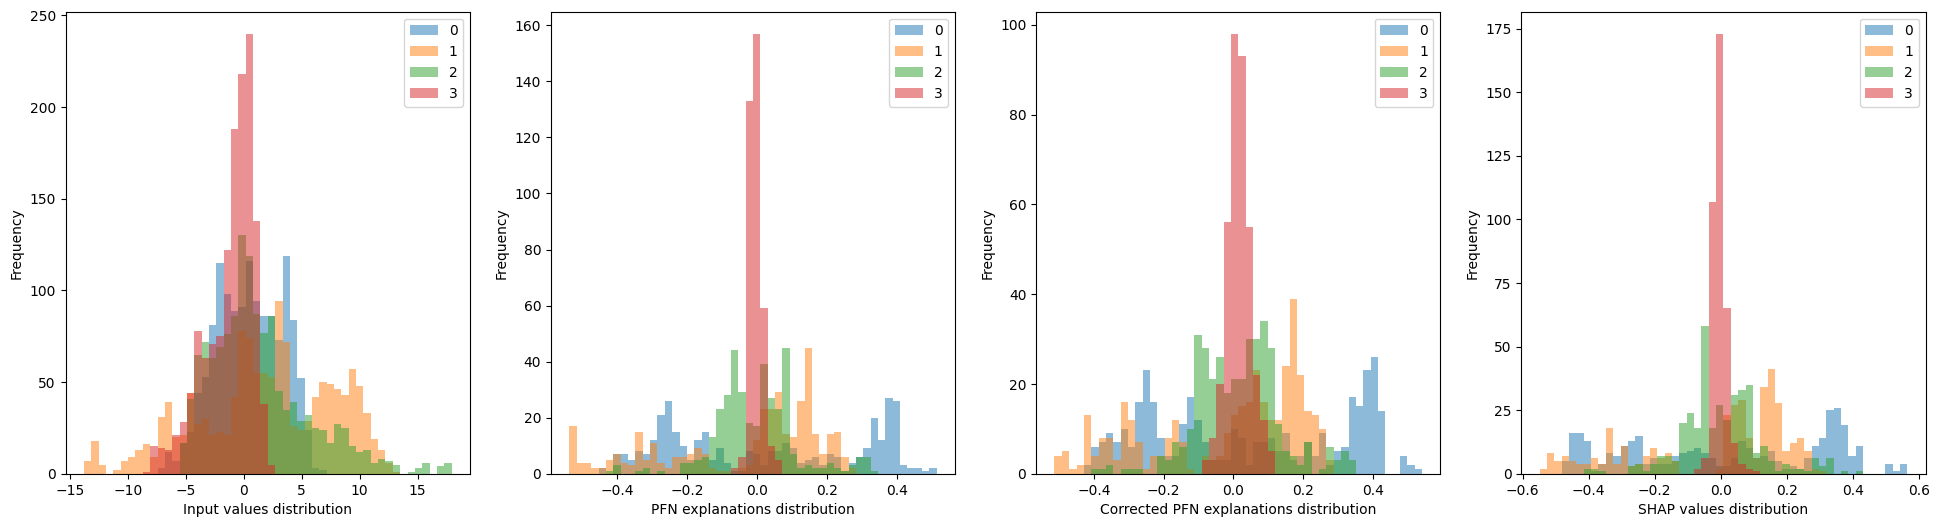

In [111]:
label_data = {
    "Input values": df.drop(columns="target"),
    "PFN explanations": df_explanations.drop(columns="target"),
    "Corrected PFN explanations": df_explanations_corrected.drop(columns="target"),
    "SHAP values": df_shap.drop(columns="target")
}

fig, axes = plt.subplots(nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6))
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50, 
        alpha=0.5, 
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")

# TESTS

In [ ]:
from tabpfn import TabPFNRegressor
pfn = TabPFNRegressor(n_estimators=1)
pfn.fit(X_train, y_train)
pfn.save_fit_state??

/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:492: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(


Signature: pfn.save_fit_state(path: 'Path | str') -> 'None'
Source:   
    def save_fit_state(self, path: Path | str) -> None:
        """Save a fitted regressor, light wrapper around save_fitted_tabpfn_model."""
        save_fitted_tabpfn_model(self, path)
File:      ~/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py
Type:      method

In [ ]:
self.interface_config_.PREPROCESS_TRANSFORMS

In [ ]:
rng = np.random.default_rng(42)
new_order = rng.permutation(np.arange(X.shape[1]))

In [ ]:
self2 = ExplainerPFN(random_state=42)
self2.fit(X[:, new_order], y)

# averaged_logits, outputs, borders = self.forward(X, np.zeros_like(y), 0)
output2 = self2.predict_feature(X[:, new_order], y, 10)

In [ ]:
np.corrcoef(output, output2)

array([[1.        , 0.85347328],
       [0.85347328, 1.        ]])

In [ ]:
output = self.forward(X, y, 0, only_return_standard_out=False)

1000


In [ ]:
quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Forward pass
(
    _,  # averaged logits (not used here)
    outputs,  # list of tensors [N_est, N_samples, N_borders] (after forward)
    borders,  # list of numpy arrays containing borders for each estimator
) = self.forward(X, y, 0, only_return_standard_out=True)

1000


In [ ]:
import torch
from tabpfn.utils import _cdf

logits = outputs[0]
borders_t = borders[0]

frm = torch.as_tensor(borders_t)
to = self.bardist_.borders

# From translate_probs_across_borders
prob_left = _cdf(logits, borders=frm, ys=to)
prob_left[..., 0] = 0.0
prob_left[..., -1] = 1.0

transformed_logits = (prob_left[..., 1:] - prob_left[..., :-1]).clamp_min(0.0)

# used to be a list comprehension
transformed_logits = [transformed_logits]

# ---- Back to predict -----
stacked_logits = torch.stack(transformed_logits, dim=0)
logits = stacked_logits.mean(dim=0)

# Post-process the logits
logits = logits.log()
if logits.dtype == torch.float16:  # TODO: Why is this needed?
    logits = logits.float()
logits = logits.cpu()




In [ ]:
self.normalized_bardist_.icdf(logits, left_prob=0.5)

tensor([ 2.1873,  2.3873,  3.9446,  4.1883,  2.2418,  3.5632,  3.1598,  4.2965,
         4.3175,  2.0113,  3.9998,  2.8345,  2.8521,  3.2601,  3.5456,  2.5292,
         4.2404,  3.6327,  3.6345,  3.5937,  2.0152,  3.7716,  2.7511,  4.2227,
         0.9948,  4.0457,  3.9713,  3.9640,  3.2406,  0.9823,  2.3698,  2.5478,
         4.0161,  4.2822,  3.7816,  3.9436,  2.7524,  4.0434,  3.6423,  3.6352,
         4.0731,  2.8178,  2.0232,  3.3596,  3.3674,  3.2984,  3.6495,  3.5857,
         2.7619,  3.9031,  4.0280,  2.5342,  3.8294,  3.6052,  3.9742,  3.5701,
         3.0751,  2.4022,  0.9933,  3.5771,  3.8784,  0.9934,  2.7762,  4.2634,
         3.5734,  3.0442,  2.8529,  0.9927,  2.3538,  3.1819,  2.9662, -1.7557,
         3.5995, -0.6597,  4.2258,  4.1749,  4.1993,  4.2692,  2.0148,  2.0148,
         3.5113,  3.9636,  3.3113,  2.8932,  3.9152,  3.6191,  2.8320,  2.0091,
        -1.4602,  4.0050,  4.1467,  3.5760,  3.8927,  1.0873,  3.7348,  0.9852,
         3.5542,  4.3455,  3.4111,  2.32

In [ ]:
transformed_logits

[tensor([[3.0982e-03, 2.0424e-04, 5.0600e-05,  ..., 3.0696e-05, 3.4213e-05,
          6.3604e-04],
         [1.2953e-10, 4.8963e-10, 1.0443e-09,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [1.5917e-04, 7.4803e-05, 4.9721e-05,  ..., 5.3406e-05, 5.6624e-05,
          1.0878e-04],
         ...,
         [2.5550e-10, 5.8007e-10, 1.0152e-09,  ..., 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [1.0464e-04, 8.9206e-05, 1.1413e-04,  ..., 6.4492e-05, 7.3373e-05,
          8.5294e-05],
         [3.8873e-06, 5.9401e-07, 2.4352e-07,  ..., 1.0729e-06, 1.1325e-06,
          5.8413e-06]])]

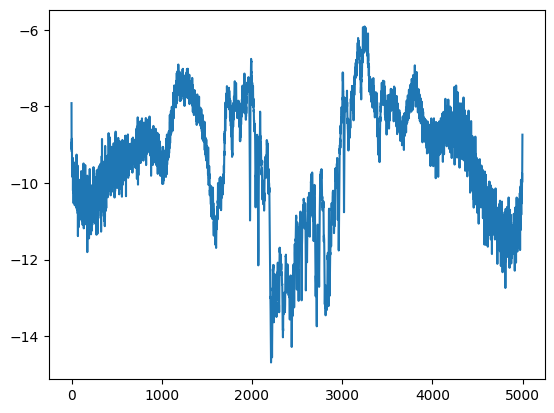

In [ ]:
plt.plot(logits[4])

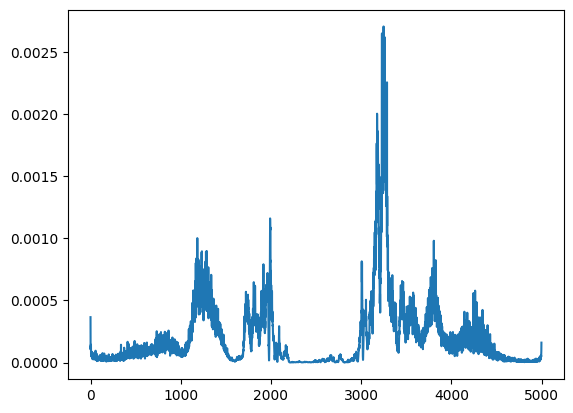

In [ ]:
import matplotlib.pyplot as plt
plt.plot(transformed_logits[0][4])

In [ ]:
output.keys()

dict_keys(['standard', 'train_embeddings', 'test_embeddings'])

In [ ]:
output["standard"][:, 0, :]

tensor([[  0.2912,  -2.1496,  -3.4139,  ...,  -3.8507,  -3.7608,  -1.1480],
        [-69.7175, -68.8766, -68.2969,  ..., -66.9017, -67.2513, -69.4174],
        [ -0.5834,  -1.5149,  -1.9847,  ...,  -1.8108,  -1.6560,  -0.8139],
        ...,
        [-60.7464, -59.9100, -59.3535,  ..., -58.3873, -58.6941, -60.2528],
        [ -3.4060,  -3.6505,  -3.4784,  ...,  -4.0261,  -3.8300,  -3.6013],
        [ -8.0860,  -9.7320, -10.5217,  ...,  -9.1362,  -9.0847,  -7.6833]])

In [ ]:
output["train_embeddings"]

tensor([[[-0.4168, -0.5051,  0.7078,  ...,  1.0717,  0.3825,  0.1117]],

        [[-0.7750, -0.8047,  0.6347,  ...,  0.7956,  0.2909,  0.2839]],

        [[-0.8041,  0.7338, -0.0193,  ...,  0.6197, -0.0415,  0.2305]],

        ...,

        [[-0.6533, -0.5422,  0.5949,  ...,  1.1625,  0.5578,  0.3583]],

        [[-0.7931,  0.8384, -0.0602,  ...,  0.6526,  0.0416,  0.3681]],

        [[-0.5737, -0.8116,  0.6617,  ...,  0.7278,  0.4975,  0.3826]]])

In [ ]:
y.reshape(-1, 1, 1).shape

(500, 1, 1)

In [ ]:
import torch
self.model_.y_encoder(torch.tensor(y.reshape(-1, 1, 1).astype(float)), single_eval_pos=0)

tensor([[[ 2.6688, -2.3322,  0.2322,  ..., -2.9595, -0.4831,  0.6856]],

        [[ 1.9647, -1.6989,  0.1914,  ..., -2.3342, -0.1968,  0.4276]],

        [[ 4.7810, -4.2323,  0.3544,  ..., -4.8353, -1.3420,  1.4595]],

        ...,

        [[ 1.9647, -1.6989,  0.1914,  ..., -2.3342, -0.1968,  0.4276]],

        [[ 6.8932, -6.1323,  0.4766,  ..., -6.7112, -2.2009,  2.2334]],

        [[ 2.6688, -2.3322,  0.2322,  ..., -2.9595, -0.4831,  0.6856]]],
       grad_fn=<ViewBackward0>)

In [ ]:
# output["standard"]

In [ ]:
averaged_logits

tensor([[  0.3235, -77.4638,  -0.6483,  ..., -67.4960,  -3.7845,  -8.9845],
        [ -2.3884, -76.5296,  -1.6833,  ..., -66.5667,  -4.0561, -10.8133],
        [ -3.7933, -75.8854,  -2.2052,  ..., -65.9484,  -3.8649, -11.6907],
        ...,
        [ -4.2785, -74.3352,  -2.0120,  ..., -64.8748,  -4.4735, -10.1513],
        [ -4.1786, -74.7237,  -1.8400,  ..., -65.2157,  -4.2556, -10.0941],
        [ -1.2756, -77.1304,  -0.9043,  ..., -66.9475,  -4.0015,  -8.5370]])

In [ ]:
self.y_.shape

(500,)

In [ ]:
# len(self.executor_.X_trains)
self.executor_.preprocessors[0].transform(X).X[:, 0].mean()

np.float64(0.49986973740630025)

In [ ]:
self.executor_.preprocessors[1].transform(X).X[:, 0].mean()

np.float64(0.49986702423007795)

In [ ]:
self.executor_.cat_ixs

([],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [])

In [ ]:
import torch
from sklearn.base import check_is_fitted
from tabpfn.utils import validate_X_predict

In [ ]:
feature_idx = 0


check_is_fitted(self)

# TODO: move to inference engine
X = validate_X_predict(X, self)


# Prepare background and input data
X_full = []
y_full = []
for X_, y_ in ([self.X_, self.y_], [X, y]):
    feature_values = X_[:, feature_idx]
    X_part = X_[:, np.arange(X_.shape[1]) != feature_idx]
    X_part = np.concatenate([feature_values.reshape(-1, 1), X_part], axis=1)
    y_full.append(y_.reshape(-1, 1))
    X_full.append(X_part)

# Concatenate all data
X_full = torch.tensor(
    np.expand_dims(np.concatenate(X_full, axis=0), 1), dtype=torch.float32
)
y_full = torch.tensor(np.concatenate(y_full, axis=0), dtype=torch.float32)

In [ ]:
with (
    torch.autocast("cpu", enabled=True),
    torch.inference_mode(True),
):
    output = self.model_(
        *(X_full, y_full),
        only_return_standard_out=True,
        categorical_inds=None,
        single_eval_pos=len(self.y_)
    )

if self.softmax_temperature != 1:
    output = output.float() / self.softmax_temperature  # noqa: PLW2901


# BSz.= 1 Scenario, the same as normal predict() function
# Handled by first if-statement
# config_for_ensemble = config
if isinstance(config, list) and len(config) == 1:
    single_config = config[0]
    config_for_ensemble = single_config


if isinstance(config_for_ensemble, RegressorEnsembleConfig):
    borders_t: np.ndarray
    logit_cancel_mask: np.ndarray | None
    descending_borders: bool

    # TODO(eddiebergman): Maybe this could be parallelized or done in fit
    # but I somehow doubt it takes much time to be worth it.
    # One reason to make it worth it is if you want fast predictions, i.e.
    # don't re-do this each time.
    # However it gets a bit more difficult as you need to line up the
    # outputs from `iter_outputs` above (which may be in arbitrary order),
    # along with the specific config the output belongs to. This is because
    # the transformation done to the borders for a given output is dependant
    # upon the target_transform of the config.
    if config_for_ensemble.target_transform is None:
        borders_t = std_borders.copy()
        logit_cancel_mask = None
        descending_borders = False
    else:
        logit_cancel_mask, descending_borders, borders_t = (
            _transform_borders_one(
                std_borders,
                target_transform=config_for_ensemble.target_transform,
                repair_nan_borders_after_transform=pfn.interface_config_.FIX_NAN_BORDERS_AFTER_TARGET_TRANSFORM,
            )
        )
        if descending_borders:
            borders_t = borders_t.flip(-1)  # type: ignore

    borders.append(borders_t)

    if logit_cancel_mask is not None:
        output = output.clone()  # noqa: PLW2901
        output[..., logit_cancel_mask] = float("-inf")

else:
    raise ValueError(
        "Unexpected config format "
        "and Batch prediction is not supported yet!"
    )

# outputs.append(output)  # type: ignore
outputs = [output]

# End of loop

averaged_logits = None
all_logits = None
if outputs:
    all_logits = torch.stack(outputs, dim=0)  # [N_est, N_sampls, N_bord]
    averaged_logits_over_ensemble = torch.mean(all_logits, dim=0)
    averaged_logits = averaged_logits_over_ensemble.transpose(0, 1)

In [ ]:
self.executor_.ensemble_configs[0]

RegressorEnsembleConfig(preprocess_config=PreprocessorConfig(name='quantile_uni', categorical_name='ordinal_very_common_categories_shuffled', append_original='auto', subsample_features=-1, global_transformer_name='svd', differentiable=False), add_fingerprint_feature=True, polynomial_features='no', feature_shift_count=np.int64(806), feature_shift_decoder='shuffle', subsample_ix=None, target_transform=None)

tensor([[[2.2315e-03, 2.1047e-04, 6.2430e-05,  ..., 6.0961e-06,
          8.0481e-06, 1.7692e-04]],

        [[1.3262e-10, 2.5048e-11, 1.7508e-10,  ..., 2.3114e-10,
          2.3114e-10, 5.3184e-10]],

        [[1.8450e-04, 7.2249e-05, 6.1264e-05,  ..., 7.0392e-05,
          7.8801e-05, 1.2163e-04]],

        ...,

        [[1.5557e-10, 2.9383e-11, 8.9257e-11,  ..., 6.7609e-11,
          6.7609e-11, 2.7114e-10]],

        [[3.3121e-04, 1.2970e-04, 1.3903e-04,  ..., 9.1655e-05,
          1.1486e-04, 1.8039e-04]],

        [[6.5231e-04, 2.1709e-05, 5.8025e-06,  ..., 4.3952e-06,
          4.7113e-06, 1.7435e-04]]])

In [ ]:
embeddings

tensor([[[ -0.4062,  -2.5312,  -3.6250,  ...,  -5.7188,  -5.4688,  -2.6875]],

        [[-54.5000, -56.0000, -54.2500,  ..., -54.0000, -54.0000, -53.2500]],

        [[ -0.6797,  -1.5234,  -1.6719,  ...,  -1.5469,  -1.4453,  -1.0547]],

        ...,

        [[-42.2500, -43.7500, -42.7500,  ..., -43.0000, -43.0000, -41.7500]],

        [[ -1.6250,  -2.4688,  -2.4062,  ...,  -2.7812,  -2.5781,  -2.1719]],

        [[ -4.0625,  -7.1250,  -8.3125,  ...,  -8.5625,  -8.5000,  -5.2500]]],
       dtype=torch.bfloat16)

In [ ]:
from tabpfn import TabPFNRegressor

model = TabPFNRegressor(n_estimators=1)
model.fit(X, y)
embeddings_tabpfn = model.get_embeddings(X)

/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:492: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
